# 04 Inflow Metallicity Experiments

This notebook performs the final Part I experiments.

The baseline and KMT regulator models are run over the same inflow metallicity grid. Only $Z_{\rm in}$ is varied while all other parameters and initial conditions remain fixed.

The results are compared through gas metallicity, molecular fraction, star formation rate, gas mass, and stellar mass.

In [1]:
import sys
from pathlib import Path
sys.path.append("../model")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from parameters import BASE_PARAMS, KMT_PARAMS, INITIAL, Z_IN_VALUES, Z_SUN, TIME
from gas_regulator import run_model as run_baseline, quantities as baseline_quantities, equilibrium_values as baseline_equilibrium
from kmt_regulator import run_model as run_kmt, quantities as kmt_quantities

figure_path = Path("../output/figures")
table_path = Path("../output/tables")
figure_path.mkdir(parents=True, exist_ok=True)
table_path.mkdir(parents=True, exist_ok=True)

## 1 Experiment setup

The controlled variable is the inflow metallicity,

$$
Z_{\rm in}.
$$

The experiment uses

$$
\frac{Z_{\rm in}}{Z_\odot}
=
[0,\ 0.05,\ 0.10,\ 0.30,\ 0.50,\ 1.00].
$$

All runs begin with the same gas mass, stellar mass, and gas metallicity. The inflow rate, return fraction, mass-loading factor, yield, gas radius, and clumping factor are also unchanged.

The 10 Gyr integration interval is used to follow the model response and approach toward equilibrium. It is not intended as a detailed reconstruction of the Milky Way history.

In [2]:
z_grid = Z_IN_VALUES / Z_SUN

print("Inflow metallicity grid")

for z_solar, z_in in zip(z_grid, Z_IN_VALUES):
    print(f"{z_solar:.2f} Z_sun = {z_in:.6f}")

Inflow metallicity grid
0.00 Z_sun = 0.000000
0.05 Z_sun = 0.000670
0.10 Z_sun = 0.001340
0.30 Z_sun = 0.004020
0.50 Z_sun = 0.006700
1.00 Z_sun = 0.013400


## 2 Baseline production runs

In the baseline model,

$$
\dot M_{\star,{\rm SF}}=\frac{M_g}{\tau_{\rm dep}}.
$$

$Z_{\rm in}$ enters only the metal evolution equation. It therefore changes $Z_g$, but does not directly change the baseline gas mass or star formation rate.

The baseline runs provide the control case for comparison with the KMT model.

In [3]:
baseline_runs = {}

for z_in in Z_IN_VALUES:
    z_solar = float(z_in / Z_SUN)
    params = BASE_PARAMS.copy()
    params["Z_in"] = z_in
    solution = run_baseline(params, INITIAL, TIME)
    baseline_runs[z_solar] = {"params": params, "solution": solution, "data": baseline_quantities(solution, params)}

print("Baseline runs completed")

Baseline runs completed


## 3 KMT production runs

In the KMT model, changing $Z_{\rm in}$ changes the evolution of $Z_g$.

This changes

$$
Z'=\frac{Z_g}{Z_\odot},
$$

which changes the molecular fraction

$$
f_{\rm H_2},
$$

and therefore the star formation rate.

The resulting change in star formation also feeds back on gas consumption, outflow, and stellar mass growth.

The regulator still requires the long-term equilibrium star formation rate to satisfy

$$
\dot M_{\star,{\rm eq}}
=
\frac{\dot M_{\rm in}}{1-R+\eta}.
$$

In [4]:
kmt_runs = {}

for z_in in Z_IN_VALUES:
    z_solar = float(z_in / Z_SUN)
    params = KMT_PARAMS.copy()
    params["Z_in"] = z_in
    solution = run_kmt(params, INITIAL, TIME)
    kmt_runs[z_solar] = {"params": params, "solution": solution, "data": kmt_quantities(solution, params)}

print("KMT runs completed")

KMT runs completed


## 4 Gas metallicity response

For both models, the equilibrium metallicity follows

$$
Z_{\rm eq}
=
Z_{\rm in}
+
\frac{y(1-R)}{1-R+\eta}.
$$

The final numerical metallicities are compared with this analytical equilibrium relation.

The two models use the same metal conservation equation, so they should approach the same equilibrium metallicity even though their evolutionary paths differ.

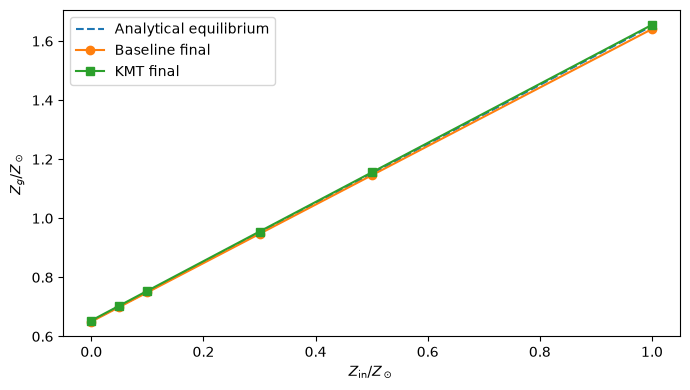

In [5]:
Z_eq = []
Z_baseline = []
Z_kmt = []

for z_solar, z_in in zip(z_grid, Z_IN_VALUES):
    key = float(z_solar)
    params = BASE_PARAMS.copy()
    params["Z_in"] = z_in

    Z_eq.append(baseline_equilibrium(params)["Z_g"] / Z_SUN)
    Z_baseline.append(baseline_runs[key]["data"]["Z_g"][-1] / Z_SUN)
    Z_kmt.append(kmt_runs[key]["data"]["Z_g"][-1] / Z_SUN)

plt.figure(figsize=(7, 4))
plt.plot(z_grid, Z_eq, linestyle="--", label="Analytical equilibrium")
plt.plot(z_grid, Z_baseline, marker="o", label="Baseline final")
plt.plot(z_grid, Z_kmt, marker="s", label="KMT final")
plt.xlabel(r"$Z_{\rm in}/Z_\odot$")
plt.ylabel(r"$Z_g/Z_\odot$")
plt.legend()
plt.tight_layout()
plt.savefig(figure_path / "metallicity_response.png", dpi=300)
plt.show()

## 5 Molecular fraction response

The baseline model has no molecular gas prescription.

In the KMT model, larger inflow metallicity increases the gas metallicity and strengthens molecular shielding. The molecular fraction should therefore become larger as $Z_{\rm in}$ increases.

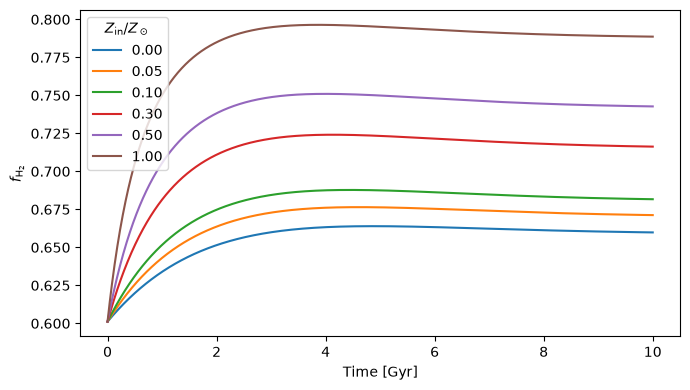

In [6]:
plt.figure(figsize=(7, 4))

for z_solar in z_grid:
    key = float(z_solar)
    plt.plot(TIME, kmt_runs[key]["data"]["f_H2"], label=f"{key:.2f}")

plt.xlabel("Time [Gyr]")
plt.ylabel(r"$f_{\rm H_2}$")
plt.legend(title=r"$Z_{\rm in}/Z_\odot$")
plt.tight_layout()
plt.savefig(figure_path / "kmt_molecular_fraction_response.png", dpi=300)
plt.show()

## 6 Star formation response

The baseline star formation rate is independent of $Z_{\rm in}$ because it depends only on gas mass and depletion time.

The KMT model introduces a metallicity-dependent transient response through $f_{\rm H_2}$.

Higher $Z_{\rm in}$ should temporarily produce a larger star formation rate. At late times, the regulator drives all runs toward approximately the same equilibrium value,

$$
\dot M_{\star,{\rm eq}}
=
\frac{\dot M_{\rm in}}{1-R+\eta}.
$$

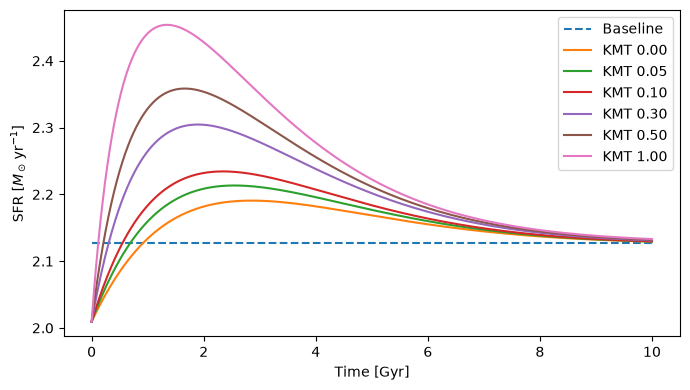

In [7]:
baseline_sfr = baseline_runs[0.0]["data"]["Mdot_star"] / 1e9

plt.figure(figsize=(7, 4))
plt.plot(TIME, baseline_sfr, linestyle="--", label="Baseline")

for z_solar in z_grid:
    key = float(z_solar)
    plt.plot(TIME, kmt_runs[key]["data"]["Mdot_star"] / 1e9, label=f"KMT {key:.2f}")

plt.xlabel("Time [Gyr]")
plt.ylabel(r"SFR [$M_\odot\,{\rm yr}^{-1}$]")
plt.legend()
plt.tight_layout()
plt.savefig(figure_path / "star_formation_response.png", dpi=300)
plt.show()

## 7 Gas mass response

The baseline gas reservoir begins in equilibrium and remains approximately constant.

In the KMT model, higher metallicity increases the molecular fraction and changes the star formation efficiency. The regulator can therefore reach the required equilibrium star formation rate with a different gas reservoir.

The gas mass response shows how the regulator compensates for the metallicity-dependent star formation law.

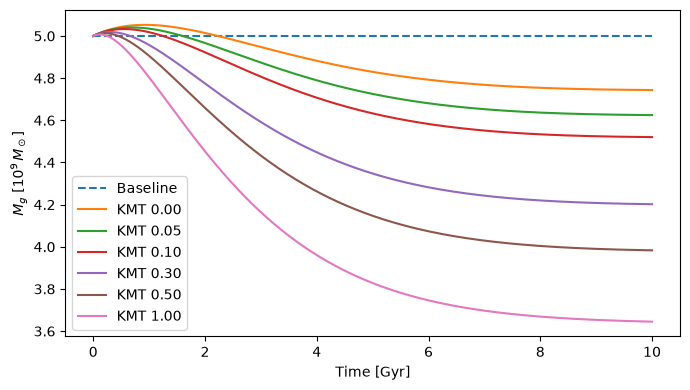

In [8]:
baseline_gas = baseline_runs[0.0]["solution"].y[0] / 1e9

plt.figure(figsize=(7, 4))
plt.plot(TIME, baseline_gas, linestyle="--", label="Baseline")

for z_solar in z_grid:
    key = float(z_solar)
    plt.plot(TIME, kmt_runs[key]["solution"].y[0] / 1e9, label=f"KMT {key:.2f}")

plt.xlabel("Time [Gyr]")
plt.ylabel(r"$M_g$ [$10^9\,M_\odot$]")
plt.legend()
plt.tight_layout()
plt.savefig(figure_path / "gas_mass_response.png", dpi=300)
plt.show()

## 8 Quantitative results

The final table summarizes the main numerical results.

The maximum SFR difference is measured relative to the pristine-inflow KMT run,

$$
\Delta_{\rm SFR}
=
100
\max
\left|
\frac{\dot M_\star(Z_{\rm in})-\dot M_\star(0)}
{\dot M_\star(0)}
\right|.
$$

This measures the largest transient star formation response caused by changing only the inflow metallicity.

The final molecular mass, gas mass, and stellar mass are also recorded to show the cumulative effect of the different KMT histories.

In [10]:
rows = []
reference_sfr = kmt_runs[0.0]["data"]["Mdot_star"] / 1e9

for z_solar, z_in in zip(z_grid, Z_IN_VALUES):
    key = float(z_solar)
    baseline = baseline_runs[key]
    kmt = kmt_runs[key]

    sfr = kmt["data"]["Mdot_star"] / 1e9
    difference = (sfr - reference_sfr) / reference_sfr
    max_index = int(np.argmax(np.abs(difference)))

    rows.append({
        "Zin_Zsun": key,
        "Zeq_Zsun": baseline_equilibrium(baseline["params"])["Z_g"] / Z_SUN,
        "Zg_baseline_final_Zsun": baseline["data"]["Z_g"][-1] / Z_SUN,
        "Zg_kmt_final_Zsun": kmt["data"]["Z_g"][-1] / Z_SUN,
        "fH2_final": kmt["data"]["f_H2"][-1],
        "MH2_final_Msun": kmt["data"]["M_H2"][-1],
        "Mgas_kmt_final_Msun": kmt["solution"].y[0, -1],
        "Mstar_kmt_final_Msun": kmt["solution"].y[1, -1],
        "SFR_kmt_peak_Msun_yr": np.max(sfr),
        "SFR_kmt_final_Msun_yr": sfr[-1],
        "Max_pointwise_SFR_diff_vs_Zin0_percent": 100 * np.max(np.abs(difference)),
        "Time_max_SFR_diff_Gyr": TIME[max_index]
    })

summary = pd.DataFrame(rows)
summary.to_csv(table_path / "inflow_metallicity_summary.csv", index=False)

summary.round({
    "Zin_Zsun": 2,
    "Zeq_Zsun": 3,
    "Zg_baseline_final_Zsun": 3,
    "Zg_kmt_final_Zsun": 3,
    "fH2_final": 3,
    "MH2_final_Msun": 0,
    "Mgas_kmt_final_Msun": 0,
    "Mstar_kmt_final_Msun": 0,
    "SFR_kmt_peak_Msun_yr": 3,
    "SFR_kmt_final_Msun_yr": 3,
    "Max_pointwise_SFR_diff_vs_Zin0_percent": 2,
    "Time_max_SFR_diff_Gyr": 2
})

,Zin_Zsun,Zeq_Zsun,Zg_baseline_final_Zsun,Zg_kmt_final_Zsun,fH2_final,MH2_final_Msun,Mgas_kmt_final_Msun,Mstar_kmt_final_Msun,SFR_kmt_peak_Msun_yr,SFR_kmt_final_Msun_yr,Max_pointwise_SFR_diff_vs_Zin0_percent,Time_max_SFR_diff_Gyr
0,0.00,0.651,0.650,0.654,0.660,3.129958e+09,4.743535e+09,6.290585e+10,2.191,2.129,0.00,0.00
1,0.05,0.701,0.699,0.704,0.671,3.104201e+09,4.624707e+09,6.297066e+10,2.213,2.129,1.28,1.48
2,0.10,0.751,0.749,0.754,0.682,3.081345e+09,4.520261e+09,6.302763e+10,2.234,2.130,2.45,1.42
3,0.30,0.951,0.947,0.955,0.716,3.009834e+09,4.202024e+09,6.320122e+10,2.305,2.131,6.26,1.26
4,0.50,1.151,1.145,1.155,0.743,2.958480e+09,3.983208e+09,6.332057e+10,2.359,2.132,9.19,1.15
5,1.00,1.651,1.641,1.655,0.789,2.874579e+09,3.644958e+09,6.350507e+10,2.454,2.133,14.41,0.97


## Parameter sensitivity

The fiducial KMT calculation adopts $c=5$ and
$R_{\rm gas}=10$ kpc. Since both parameters affect the surface density entering the molecular-gas prescription, a limited sensitivity test is performed to determine whether the qualitative result depends on these assumptions.

In [11]:
def maximum_sfr_response(clumping_factor, R_gas):
    pristine_params = KMT_PARAMS.copy()
    enriched_params = KMT_PARAMS.copy()

    pristine_params["Z_in"] = 0.0
    enriched_params["Z_in"] = Z_SUN

    pristine_params["clumping_factor"] = clumping_factor
    enriched_params["clumping_factor"] = clumping_factor

    pristine_params["R_gas"] = R_gas
    enriched_params["R_gas"] = R_gas

    pristine_solution = run_kmt(
        pristine_params,
        INITIAL,
        TIME
    )

    enriched_solution = run_kmt(
        enriched_params,
        INITIAL,
        TIME
    )

    pristine_sfr = (
        kmt_quantities(
            pristine_solution,
            pristine_params
        )["Mdot_star"]
    )

    enriched_sfr = (
        kmt_quantities(
            enriched_solution,
            enriched_params
        )["Mdot_star"]
    )

    difference = (
        enriched_sfr - pristine_sfr
    ) / pristine_sfr

    return 100 * np.max(np.abs(difference))


print("Clumping-factor sensitivity")

for c in [3.0, 5.0, 10.0]:
    response = maximum_sfr_response(
        clumping_factor=c,
        R_gas=10.0
    )

    print(
        f"c = {c:.1f}: "
        f"maximum SFR response = {response:.2f}%"
    )


print("\nGas-radius sensitivity")

for radius in [8.0, 10.0, 12.0]:
    response = maximum_sfr_response(
        clumping_factor=5.0,
        R_gas=radius
    )

    print(
        f"R_gas = {radius:.1f} kpc: "
        f"maximum SFR response = {response:.2f}%"
    )

Clumping-factor sensitivity
c = 3.0: maximum SFR response = 37.63%
c = 5.0: maximum SFR response = 14.41%
c = 10.0: maximum SFR response = 5.73%

Gas-radius sensitivity
R_gas = 8.0 kpc: maximum SFR response = 8.18%
R_gas = 10.0 kpc: maximum SFR response = 14.41%
R_gas = 12.0 kpc: maximum SFR response = 26.22%


## 9 Final result

The baseline model responds to inflow metallicity only through the metal reservoir. Its gas mass and star formation rate remain unchanged because the baseline star formation law has no metallicity dependence.

The KMT model produces an additional transient response. Higher $Z_{\rm in}$ increases $Z_g$ and $f_{\rm H_2}$, which temporarily increases the star formation rate.

The largest response occurs for $Z_{\rm in}=Z_\odot$. The maximum point-by-point fractional separation in SFR relative to the pristine-inflow run is approximately $14.4\%$, occurring at about $0.97$ Gyr. This quantity measures the largest fractional difference between the two SFR histories at the same time; it is not the difference between their individual peak SFR values.

The regulator subsequently compensates through an adjustment of the gas reservoir. As equilibrium is approached, the different KMT runs return toward nearly the same star formation rate because the equilibrium SFR is determined by the imposed inflow rate, return fraction, and mass-loading factor.

Therefore, within the adopted one-zone parameterization, inflow metallicity produces a measurable transient effect on molecular fraction and star formation, while the regulator suppresses differences in the long-term equilibrium star formation rate. The numerical amplitude of this transient response depends on the adopted one-zone geometry and clumping factor.